# **Seccción I: Estracción, Estandarización y Análisis**

# **1. Extracción**

In [83]:
import pandas as pd

In [84]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

In [85]:
# Explorando los datos
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# **2. Estandarización y transformación de datos**

In [86]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [87]:
columnas = ['customer', 'phone', 'internet', 'account']
datos = [df.drop(columns=columnas)]
datos.append(customer)
datos.append(phone)
datos.append(internet)
datos.append(account)

datos = pd.concat(datos, axis=1)
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [88]:
# Explorando los tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [89]:
import numpy as np

# Cambiando el tipo de dato de Charges.Total a float64
charges_total = np.where(datos['Charges.Total'].str.strip() == '', np.nan, datos['Charges.Total'])
datos['Charges.Total'] = np.array(charges_total, dtype=np.float64)

In [90]:
# Cambiando los valores de SeniorCitizen a No y Yes, para estandarizar los datos
datos['SeniorCitizen'] = datos['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [91]:
# Verificando los cambios de tipos de datos realizados
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   object 
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [92]:
# Verificando el cambio de valores de SeniorCitizen
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [93]:
# Verificando si existen valores nulos en Charges.Total
nulos_charges_total = datos['Charges.Total'].isnull().sum()
print(f"Existen {nulos_charges_total} valores nulos en Charges.Total")

Existen 11 valores nulos en Charges.Total


In [94]:
# Reemplazando valores nulos por 0.0 en Charges.Total
datos['Charges.Total'] = datos['Charges.Total'].fillna(0.0)

# Verificando si existen valores nulos en Charges.Total
print(f"Existen {datos['Charges.Total'].isnull().sum()} valores nulos en Charges.Total")

Existen 0 valores nulos en Charges.Total


In [95]:
# Extrayendo valores unicos de cada columna para analizar los datos
columnas = datos.select_dtypes(include=['object']).columns
for col in columnas:
    print(f"Columna: {col}")
    print(f"Valores: {datos[col].unique()}")
    print("-" * 30)

Columna: customerID
Valores: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------------------------------
Columna: Churn
Valores: ['No' 'Yes' '']
------------------------------
Columna: gender
Valores: ['Female' 'Male']
------------------------------
Columna: SeniorCitizen
Valores: ['No' 'Yes']
------------------------------
Columna: Partner
Valores: ['Yes' 'No']
------------------------------
Columna: Dependents
Valores: ['Yes' 'No']
------------------------------
Columna: PhoneService
Valores: ['Yes' 'No']
------------------------------
Columna: MultipleLines
Valores: ['No' 'Yes' 'No phone service']
------------------------------
Columna: InternetService
Valores: ['DSL' 'Fiber optic' 'No']
------------------------------
Columna: OnlineSecurity
Valores: ['No' 'Yes' 'No internet service']
------------------------------
Columna: OnlineBackup
Valores: ['Yes' 'No' 'No internet service']
------------------------------
Columna: DeviceProtection
Valores

In [96]:
# Encontrando el número y porcentaje de datos vacios en Churn
conteo_churn = datos['Churn'].value_counts()
print(conteo_churn)

vacios = (datos['Churn'] == '').sum()
print(f"\nValores vacíos: {vacios}")

porcentaje_vacios = (vacios / len(datos)) * 100
print(f"Porecentaje de vacios: {porcentaje_vacios:.2f}%")

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Valores vacíos: 224
Porecentaje de vacios: 3.08%


In [97]:
# Eliminando filas del data frame cuando la columna Churn tiene dato vacios
datos = datos[datos['Churn'] != ''].copy()
datos = datos.reset_index(drop=True)

In [98]:
# Estandarizando los valores de las columnas
columnas = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas:
    datos[col] = datos[col].replace({'No internet service': 'No', 'No phone service': 'No'})

In [99]:
# Comprobando valores únicos en columnas
columnas = datos.select_dtypes(include=['object']).columns
for col in columnas:
    print(f"Columna: {col}")
    print(f"Valores: {datos[col].unique()}")
    print("-" * 30)

Columna: customerID
Valores: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------------------------------
Columna: Churn
Valores: ['No' 'Yes']
------------------------------
Columna: gender
Valores: ['Female' 'Male']
------------------------------
Columna: SeniorCitizen
Valores: ['No' 'Yes']
------------------------------
Columna: Partner
Valores: ['Yes' 'No']
------------------------------
Columna: Dependents
Valores: ['Yes' 'No']
------------------------------
Columna: PhoneService
Valores: ['Yes' 'No']
------------------------------
Columna: MultipleLines
Valores: ['No' 'Yes']
------------------------------
Columna: InternetService
Valores: ['DSL' 'Fiber optic' 'No']
------------------------------
Columna: OnlineSecurity
Valores: ['No' 'Yes']
------------------------------
Columna: OnlineBackup
Valores: ['Yes' 'No']
------------------------------
Columna: DeviceProtection
Valores: ['No' 'Yes']
------------------------------
Columna: TechSupport

In [100]:
# Transformando valores de columnas con dos categorías
columnas = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in columnas:
    datos[col] = datos[col].map({'Yes': 1, 'No': 0})

In [101]:
# Transformando los valores de la columna gender
datos['gender'] = datos['gender'].map({'Male': 1, 'Female': 0})

In [102]:
# Explotando las columnas de varias categorías
columnas = ['InternetService', 'Contract', 'PaymentMethod']
datos = pd.get_dummies(datos, columns=columnas, drop_first=True, dtype=int)

In [103]:
# Estandarizando los nombres de las columnas
datos.columns = [col.replace('.', '_').replace(' ', '_').replace('(', '').replace(')', '') for col in datos.columns]

In [104]:
# Verificando transformaciones
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,...,PaperlessBilling,Charges_Monthly,Charges_Total,InternetService_Fiber_optic,InternetService_No,Contract_One_year,Contract_Two_year,PaymentMethod_Credit_card_automatic,PaymentMethod_Electronic_check,PaymentMethod_Mailed_check
0,0002-ORFBO,0,0,0,1,1,9,1,0,0,...,1,65.6,593.30,0,0,1,0,0,0,1
1,0003-MKNFE,0,1,0,0,0,9,1,1,0,...,0,59.9,542.40,0,0,0,0,0,0,1
2,0004-TLHLJ,1,1,0,0,0,4,1,0,0,...,1,73.9,280.85,1,0,0,0,0,1,0
3,0011-IGKFF,1,1,1,1,0,13,1,0,0,...,1,98.0,1237.85,1,0,0,0,0,1,0
4,0013-EXCHZ,1,0,1,1,0,3,1,0,0,...,1,83.9,267.40,1,0,0,0,0,0,1


In [105]:
# Verificando tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customerID                           7043 non-null   object 
 1   Churn                                7043 non-null   int64  
 2   gender                               7043 non-null   int64  
 3   SeniorCitizen                        7043 non-null   int64  
 4   Partner                              7043 non-null   int64  
 5   Dependents                           7043 non-null   int64  
 6   tenure                               7043 non-null   int64  
 7   PhoneService                         7043 non-null   int64  
 8   MultipleLines                        7043 non-null   int64  
 9   OnlineSecurity                       7043 non-null   int64  
 10  OnlineBackup                         7043 non-null   int64  
 11  DeviceProtection              

In [106]:
# Creación de la columna Cuentas_Diarias basándonos en un mes de 30 días
datos['Cuentas_Diarias'] = datos['Charges_Monthly'] / 30

# **3. Análisis**

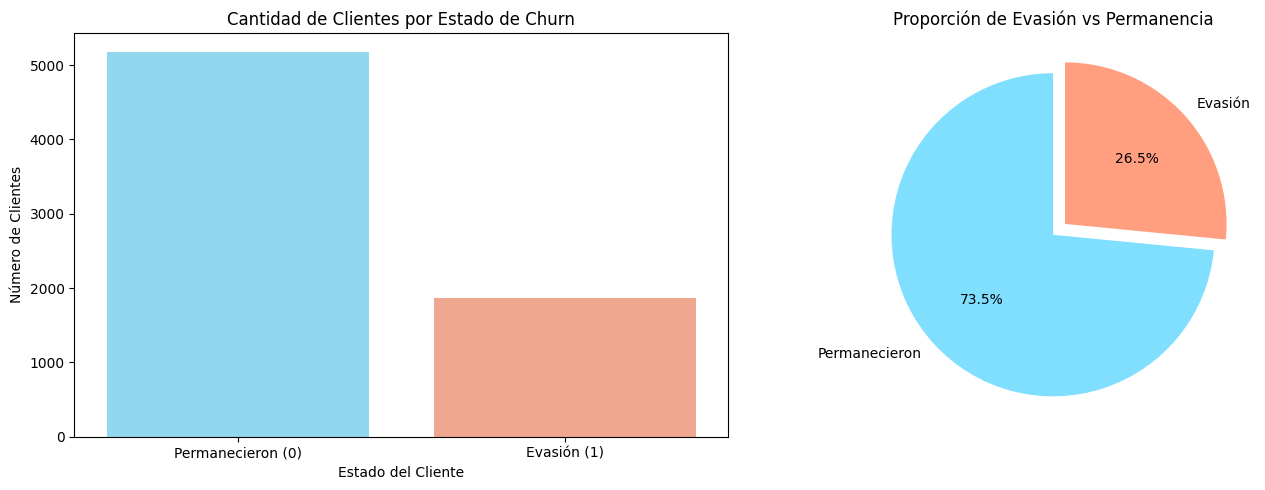

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_resumen_churn():
  # Definiendo los colores
  color_map_pastel = {0: '#80DFFF', 1: '#FF9F80'}
  # Calculando el conteo
  churn_conteo = datos['Churn'].value_counts()

  # Configurando el lienzo
  fig, ax = plt.subplots(1, 2, figsize=(14, 5))

  # Gráfico de barras
  sns.countplot(x='Churn', data=datos, ax=ax[0], hue='Churn', palette=color_map_pastel, legend=False)
  ax[0].set_title('Cantidad de Clientes por Estado de Churn')
  ax[0].set_ylabel('Número de Clientes')
  ax[0].set_xlabel('Estado del Cliente')
  ax[0].set_xticks([0, 1])
  ax[0].set_xticklabels(['Permanecieron (0)', 'Evasión (1)'])

  # Gráfico pie
  ax[1].pie(churn_conteo, labels=['Permanecieron', 'Evasión'], autopct='%1.1f%%',
          startangle=90, colors=['#80DFFF', '#FF9F80'], explode=(0, 0.1))
  ax[1].set_title('Proporción de Evasión vs Permanencia')

  plt.tight_layout()
  plt.show()

graficar_resumen_churn()

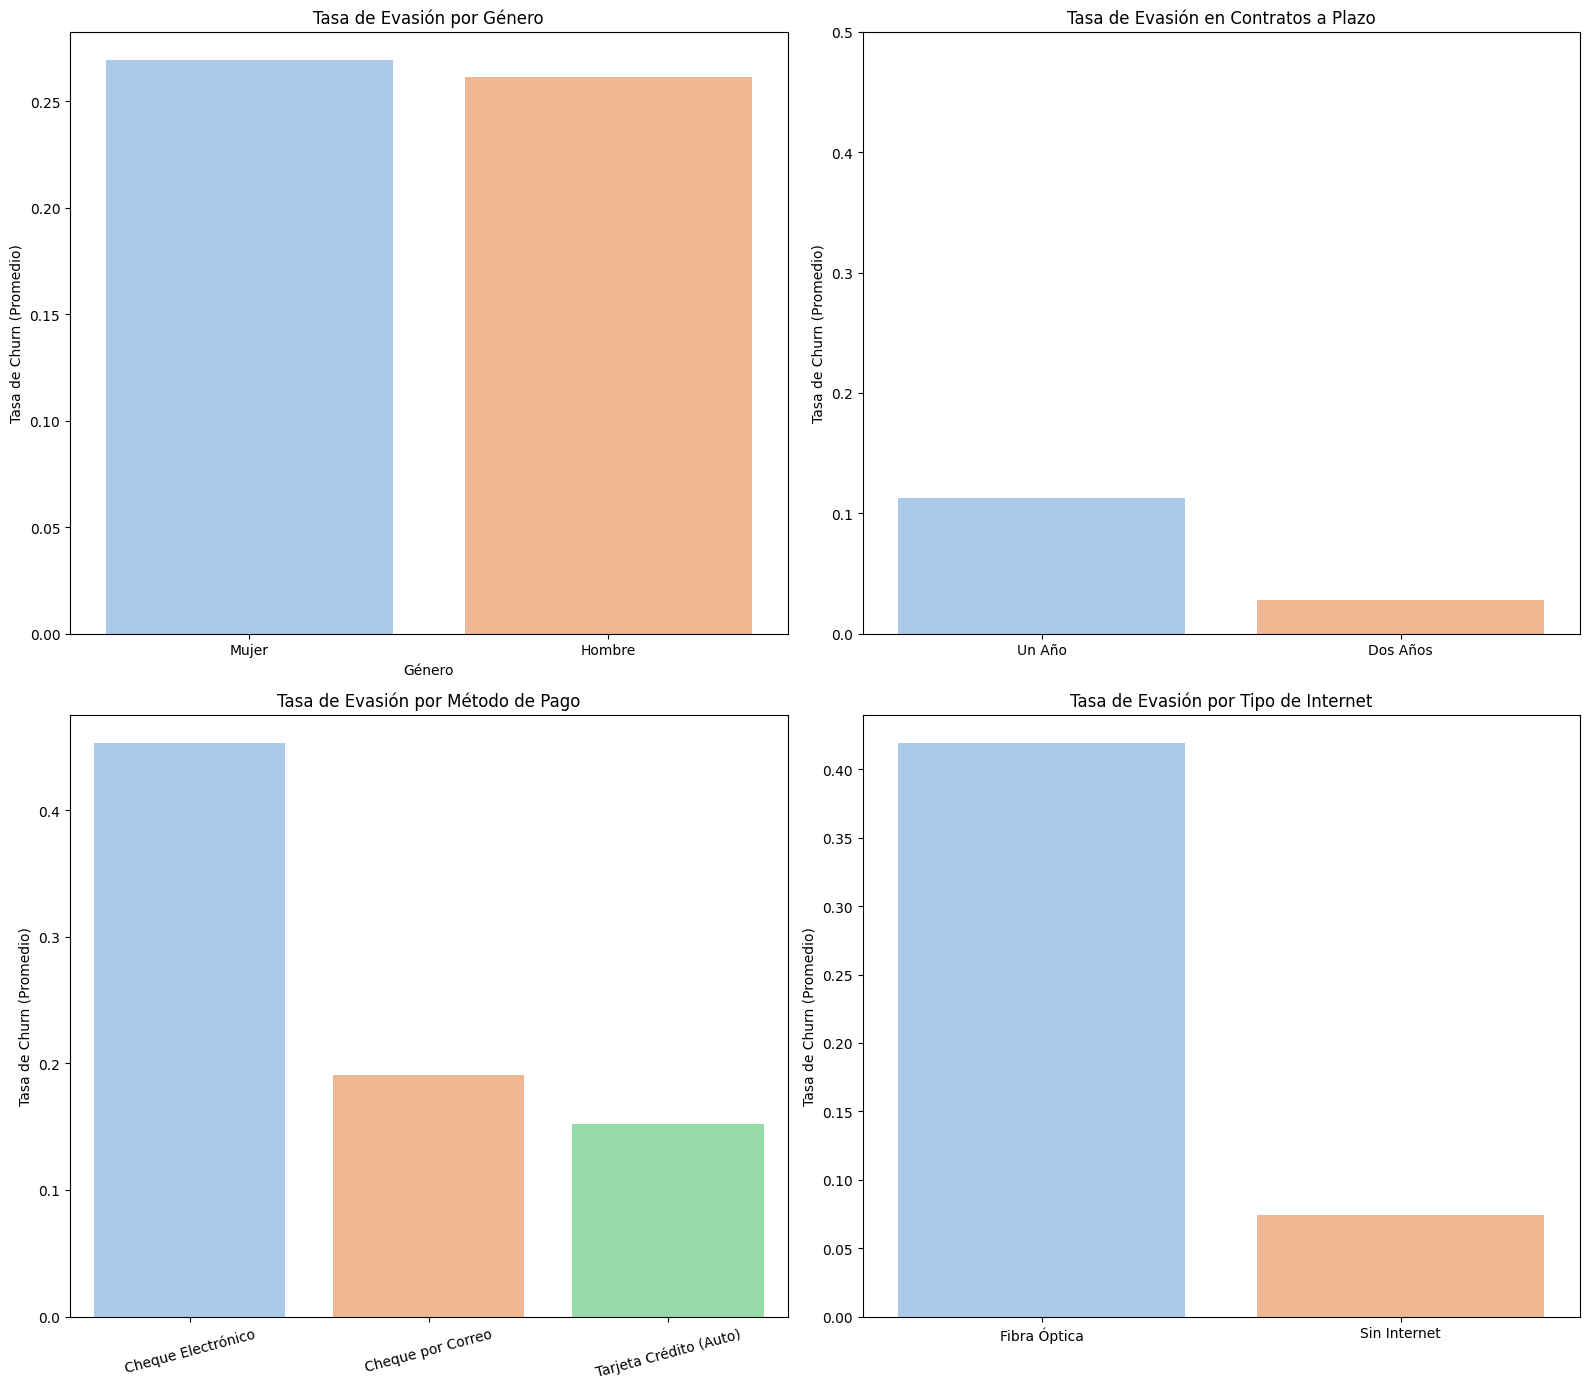

In [108]:
# Configuramos el lienzo
plt.figure(figsize=(16, 14))

# Análisis por género
plt.subplot(2, 2, 1)
sns.barplot(x='gender', y='Churn', data=datos, hue='gender', palette='pastel', legend=False, errorbar=None)
plt.title('Tasa de Evasión por Género')
plt.ylabel('Tasa de Churn (Promedio)')
plt.xlabel('Género')
plt.xticks([0, 1], ['Mujer', 'Hombre'])

# Análisis por tipo de contrato
un_anio = datos[datos['Contract_One_year'] == 1]['Churn'].mean()
dos_anios = datos[datos['Contract_Two_year'] == 1]['Churn'].mean()
plt.subplot(2, 2, 2)
nombres_contrato = ['Un Año', 'Dos Años']
valores_contrato = [un_anio, dos_anios]
sns.barplot(x=nombres_contrato, y=valores_contrato, palette='pastel', hue=nombres_contrato, legend=False)
plt.title('Tasa de Evasión en Contratos a Plazo')
plt.ylabel('Tasa de Churn (Promedio)')
plt.ylim(0, 0.5)

# Análisis por método de pago
electronico = datos[datos['PaymentMethod_Electronic_check'] == 1]['Churn'].mean()
mail = datos[datos['PaymentMethod_Mailed_check'] == 1]['Churn'].mean()
credito = datos[datos['PaymentMethod_Credit_card_automatic'] == 1]['Churn'].mean()
plt.subplot(2, 2, 3)
nombres_pago = ['Cheque Electrónico', 'Cheque por Correo', 'Tarjeta Crédito (Auto)']
metodos_pago = [electronico, mail, credito]
sns.barplot(x=nombres_pago, y=metodos_pago, palette='pastel', hue=nombres_pago, legend=False)
plt.title('Tasa de Evasión por Método de Pago')
plt.ylabel('Tasa de Churn (Promedio)')
plt.xticks(rotation=15)

# Análisis por servicio de internet
fibra = datos[datos['InternetService_Fiber_optic'] == 1]['Churn'].mean()
sin_internet = datos[datos['InternetService_No'] == 1]['Churn'].mean()
plt.subplot(2, 2, 4)
nombres_int = ['Fibra Óptica', 'Sin Internet']
valores_internet = [fibra, sin_internet]
sns.barplot(x=nombres_int, y=valores_internet, palette='pastel', hue=nombres_int, legend=False)
plt.title('Tasa de Evasión por Tipo de Internet')
plt.ylabel('Tasa de Churn (Promedio)')

plt.tight_layout()
plt.show()

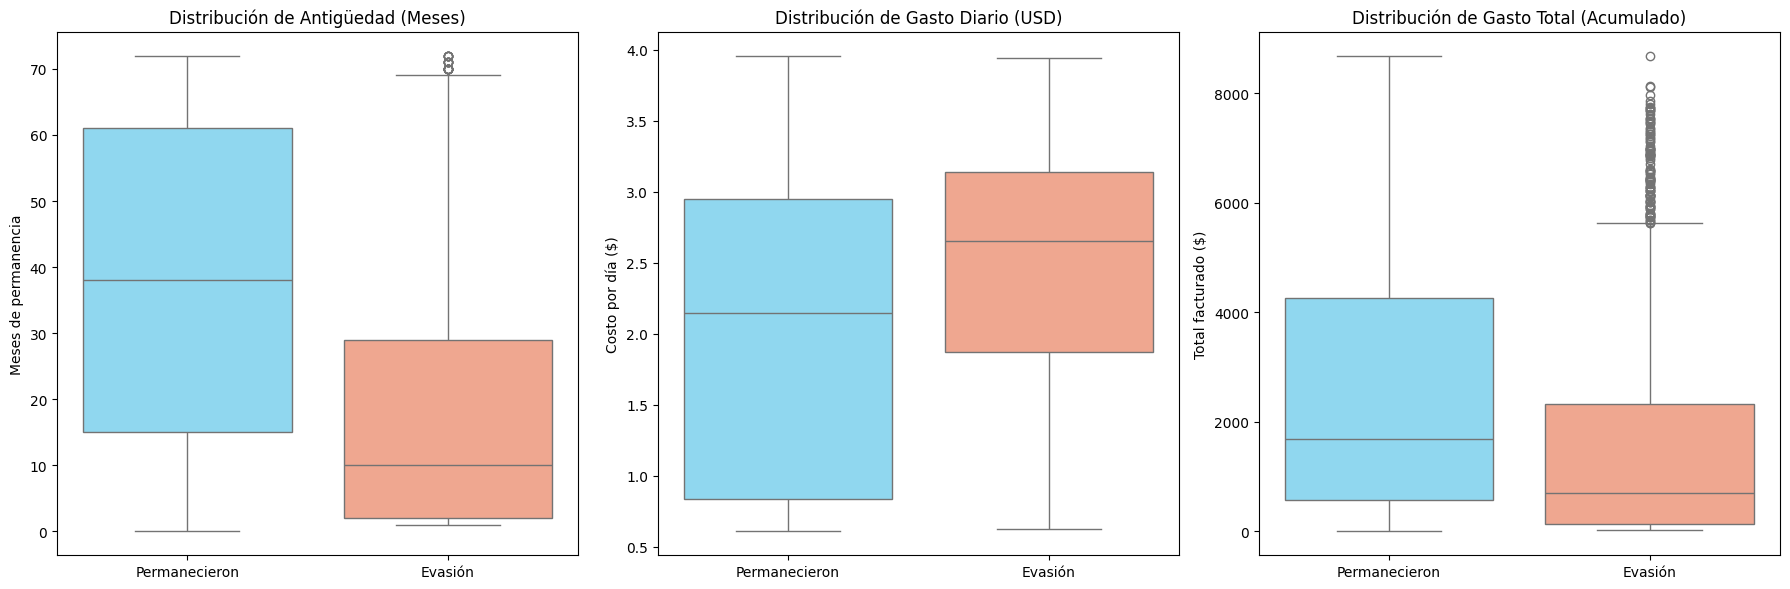

In [109]:
colores_maestros = {0: '#80DFFF', 1: '#FF9F80'}

# Configurando el lienzo
plt.figure(figsize=(18, 6))

# Antigüedad: ¿Influye el tiempo que llevan con nosotros en la decisión de irse?
plt.subplot(1, 3, 1)
sns.boxplot(x='Churn', y='tenure', data=datos, hue='Churn', palette=colores_maestros, legend=False)
plt.title('Distribución de Antigüedad (Meses)')
plt.xticks([0, 1], ['Permanecieron', 'Evasión'])
plt.xlabel('')
plt.ylabel('Meses de permanencia')

# Gasto Diario: ¿Los que se van pagan más al día que los que se quedan?
plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='Cuentas_Diarias', data=datos, hue='Churn', palette=colores_maestros, legend=False)
plt.title('Distribución de Gasto Diario (USD)')
plt.xticks([0, 1], ['Permanecieron', 'Evasión'])
plt.xlabel('')
plt.ylabel('Costo por día ($)')

# Gasto Total: ¿Cuál es el valor acumulado de los clientes?
plt.subplot(1, 3, 3)
sns.boxplot(x='Churn', y='Charges_Total', data=datos, hue='Churn', palette=colores_maestros, legend=False)
plt.title('Distribución de Gasto Total (Acumulado)')
plt.xticks([0, 1], ['Permanecieron', 'Evasión'])
plt.xlabel('')
plt.ylabel('Total facturado ($)')

plt.tight_layout()
plt.show()

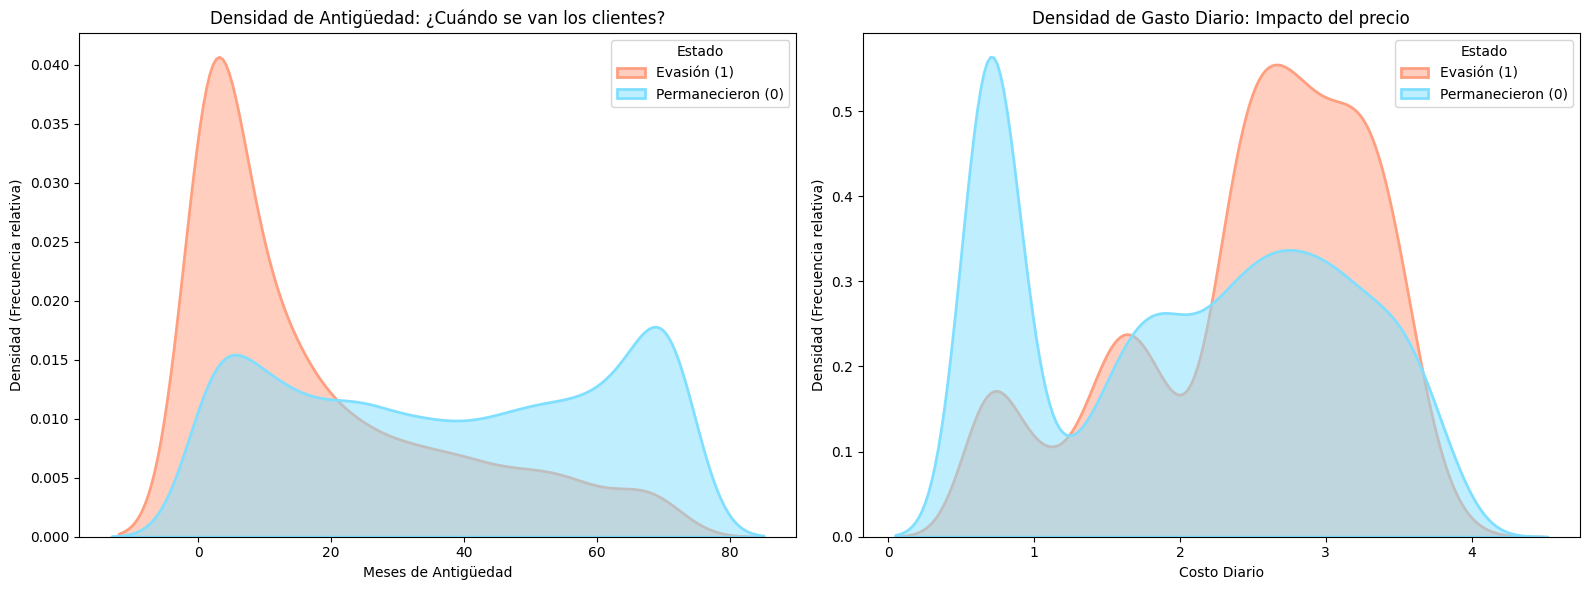

In [110]:
colores_maestros = {0: '#80DFFF', 1: '#FF9F80'}

# Configurando
plt.figure(figsize=(16, 6))

# Analizando el pico de abandonos en los primeros meses
plt.subplot(1, 2, 1)
sns.kdeplot(data=datos, x='tenure', hue='Churn', palette=colores_maestros, fill=True, common_norm=False, alpha=0.5, linewidth=2)
plt.title('Densidad de Antigüedad: ¿Cuándo se van los clientes?')
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Densidad (Frecuencia relativa)')
plt.legend(title='Estado', labels=['Evasión (1)', 'Permanecieron (0)'])

# Analizando en qué rango de precio se concentra el abandono
plt.subplot(1, 2, 2)
sns.kdeplot(data=datos, x='Cuentas_Diarias', hue='Churn', palette=colores_maestros, fill=True, common_norm=False, alpha=0.5, linewidth=2)
plt.title('Densidad de Gasto Diario: Impacto del precio')
plt.xlabel('Costo Diario')
plt.ylabel('Densidad (Frecuencia relativa)')
plt.legend(title='Estado', labels=['Evasión (1)', 'Permanecieron (0)'])

plt.tight_layout()
plt.show()

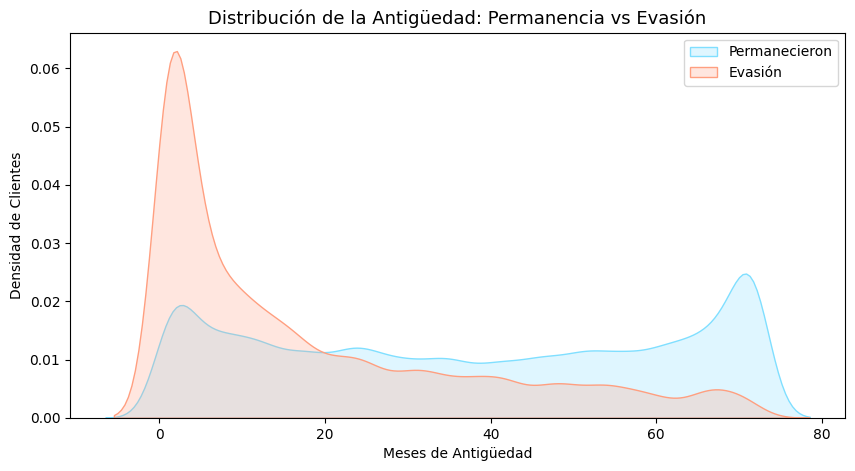

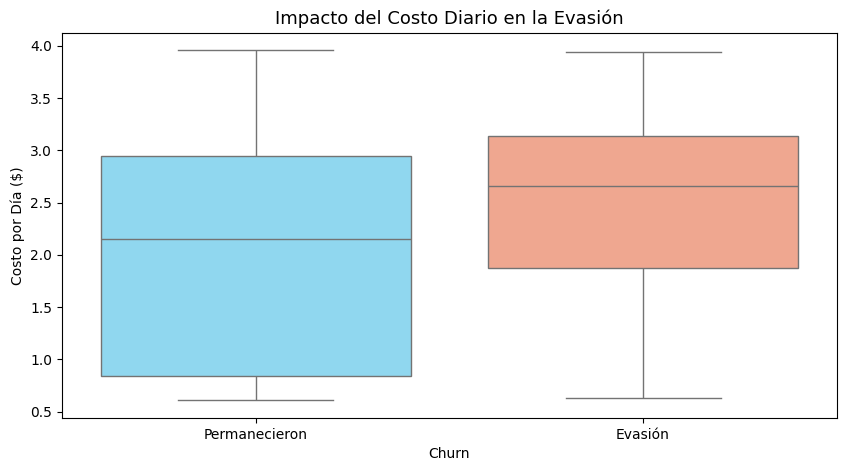

In [111]:
def graficar_diagnostico():
  # 1. Relación entre Antigüedad y Evasión
  plt.figure(figsize=(10, 5))
  sns.kdeplot(datos[datos['Churn'] == 0]['tenure'], fill=True, color='#80DFFF', label='Permanecieron', bw_adjust=0.5)
  sns.kdeplot(datos[datos['Churn'] == 1]['tenure'], fill=True, color='#FF9F80', label='Evasión', bw_adjust=0.5)
  plt.title('Distribución de la Antigüedad: Permanencia vs Evasión', fontsize=13)
  plt.xlabel('Meses de Antigüedad')
  plt.ylabel('Densidad de Clientes')
  plt.legend()
  plt.show()

  # 2. Análisis del Impacto del Costo Diario
  plt.figure(figsize=(10, 5))
  sns.boxplot(x='Churn', y='Cuentas_Diarias', data=datos, palette=colores_maestros, hue='Churn', legend=False)
  plt.title('Impacto del Costo Diario en la Evasión', fontsize=13)
  plt.xticks([0, 1], ['Permanecieron', 'Evasión'])
  plt.ylabel('Costo por Día ($)')
  plt.show()

graficar_diagnostico()

In [112]:
from scipy.stats import skew, kurtosis

# Columnas de análisis
columnas = ['tenure', 'Charges_Total', 'Cuentas_Diarias']

resumen = datos[columnas].describe().T

# Asimetría
resumen['Asimetria'] = datos[columnas].apply(lambda x: skew(x.dropna()))

# Curtosis
resumen['Curtosis'] = datos[columnas].apply(lambda x: kurtosis(x.dropna()))

# Coeficiente de Variación
resumen['CV'] = resumen['std'] / resumen['mean']

# Reporte
print(resumen[['mean', 'std', '50%', 'Asimetria', 'Curtosis', 'CV']].round(3))

                     mean       std       50%  Asimetria  Curtosis     CV
tenure             32.371    24.559    29.000      0.239    -1.387  0.759
Charges_Total    2279.734  2266.794  1394.550      0.963    -0.229  0.994
Cuentas_Diarias     2.159     1.003     2.345     -0.220    -1.257  0.465


In [113]:
# Columnas de análisis
columnas_numericas = ['tenure', 'Charges_Total', 'Cuentas_Diarias']

resultados_outliers = {}

for col in columnas_numericas:
    # Calculamos los cuartiles Q1 y Q3
    Q1 = datos[col].quantile(0.25)
    Q3 = datos[col].quantile(0.75)

    # Rango Intercuartílico
    IQR = Q3 - Q1

    # Límites estadísticos
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Valores fuera de los límites
    outliers = datos[(datos[col] < limite_inferior) | (datos[col] > limite_superior)]

    # Almacenando hallazgo
    resultados_outliers[col] = {
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Límite Inferior': round(limite_inferior, 2),
        'Límite Superior': round(limite_superior, 2),
        'Cant. Outliers': len(outliers),
        '% de Outliers': round((len(outliers) / len(datos)) * 100, 2)
    }

# Convirtirendo a DataFrame
datos_outliers = pd.DataFrame(resultados_outliers).T
# Reporte
print(datos_outliers)

                     Q1       Q3      IQR  Límite Inferior  Límite Superior  \
tenure             9.00    55.00    46.00           -60.00           124.00   
Charges_Total    398.55  3786.60  3388.05         -4683.52          8868.67   
Cuentas_Diarias    1.18     2.99     1.81            -1.53             5.71   

                 Cant. Outliers  % de Outliers  
tenure                      0.0            0.0  
Charges_Total               0.0            0.0  
Cuentas_Diarias             0.0            0.0  


In [114]:
from scipy.stats import levene

# Filtrando los datos
quedan = datos[datos['Churn'] == 0]
se_van = datos[datos['Churn'] == 1]

# Columnas de análisis
columnas = ['tenure', 'Charges_Total', 'Cuentas_Diarias']

# Reporte
print(f"{'Variable':<18} | {'Estadístico':<12} | {'p-valor':<10} | {'Resultado'}")
print("-" * 65)

# Prueba de Levene
for var in columnas:
    stat, p_val = levene(quedan[var], se_van[var])
    # Si p > 0.05, las varianzas son iguales (Homocedasticidad)
    # Si p < 0.05, las varianzas son distintas (Heterocedasticidad)
    resultado = "Varianzas IGUALES" if p_val > 0.05 else "Varianzas DISTINTAS"

    # Cuerpop reporte
    print(f"{var:<18} | {stat:<12.4f} | {p_val:<10.4f} | {resultado}")

Variable           | Estadístico  | p-valor    | Resultado
-----------------------------------------------------------------
tenure             | 417.1696     | 0.0000     | Varianzas DISTINTAS
Charges_Total      | 166.3004     | 0.0000     | Varianzas DISTINTAS
Cuentas_Diarias    | 361.8445     | 0.0000     | Varianzas DISTINTAS


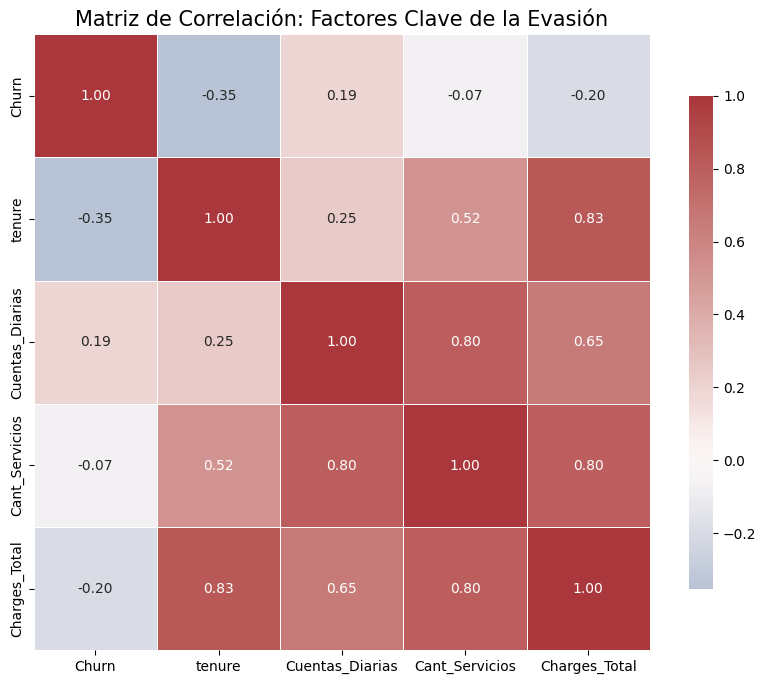

In [115]:
# Columnas de análisis
columnas_servicios = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Creando la columna Cant_Servicios
servicios_presentes = [col for col in columnas_servicios if col in datos.columns]
datos['Cant_Servicios'] = datos[servicios_presentes].sum(axis=1)

# Columnas para correlación
columnas_correlacion = ['Churn', 'tenure', 'Cuentas_Diarias', 'Cant_Servicios', 'Charges_Total']
matriz = datos[columnas_correlacion].corr()

# 3. Visualización con Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
# Usamos una paleta pastel divergente (vlag o Rocket_r son geniales)
sns.heatmap(matriz, annot=True, fmt=".2f", cmap='vlag', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación: Factores Clave de la Evasión', fontsize=15)
plt.show()

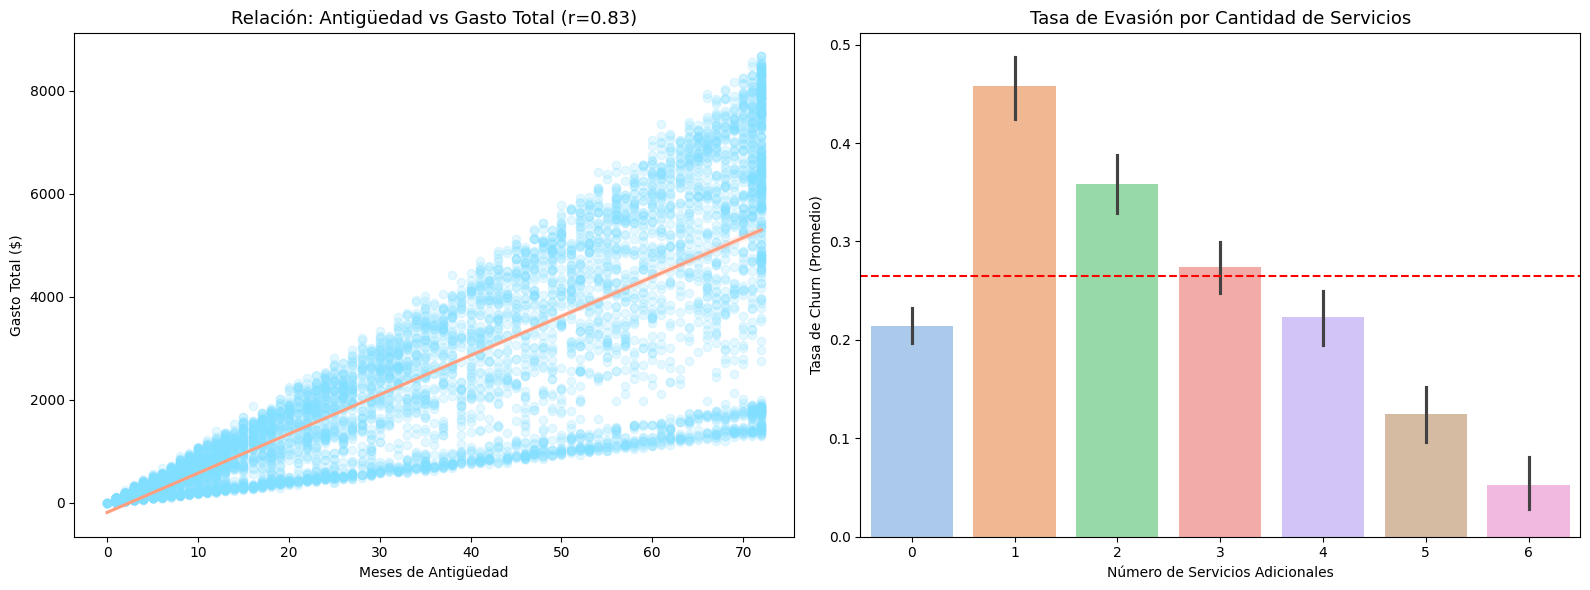

In [116]:
# Columnas de análisis
servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']

# Creando la columna Cant_Servicios
servicios_existentes = [s for s in servicios if s in datos.columns]
datos['Cant_Servicios'] = datos[servicios_existentes].sum(axis=1)

# Configurando el lienzo
plt.figure(figsize=(16, 6))

# Correlación entre Antigüedad y Gasto Total
plt.subplot(1, 2, 1)
sns.regplot(x='tenure', y='Charges_Total', data=datos,
            scatter_kws={'alpha':0.2, 'color':'#80DFFF'},
            line_kws={'color':'#FF9F80'})
plt.title('Relación: Antigüedad vs Gasto Total (r=0.83)', fontsize=13)
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Gasto Total ($)')

# Graficando como la permanencia cae cuanto mas servicios tiene
plt.subplot(1, 2, 2)
sns.barplot(x='Cant_Servicios', y='Churn', data=datos, palette='pastel', hue='Cant_Servicios', legend=False)
plt.axhline(datos['Churn'].mean(), color='red', linestyle='--', label='Promedio General')
plt.title('Tasa de Evasión por Cantidad de Servicios', fontsize=13)
plt.ylabel('Tasa de Churn (Promedio)')
plt.xlabel('Número de Servicios Adicionales')

plt.tight_layout()
plt.show()

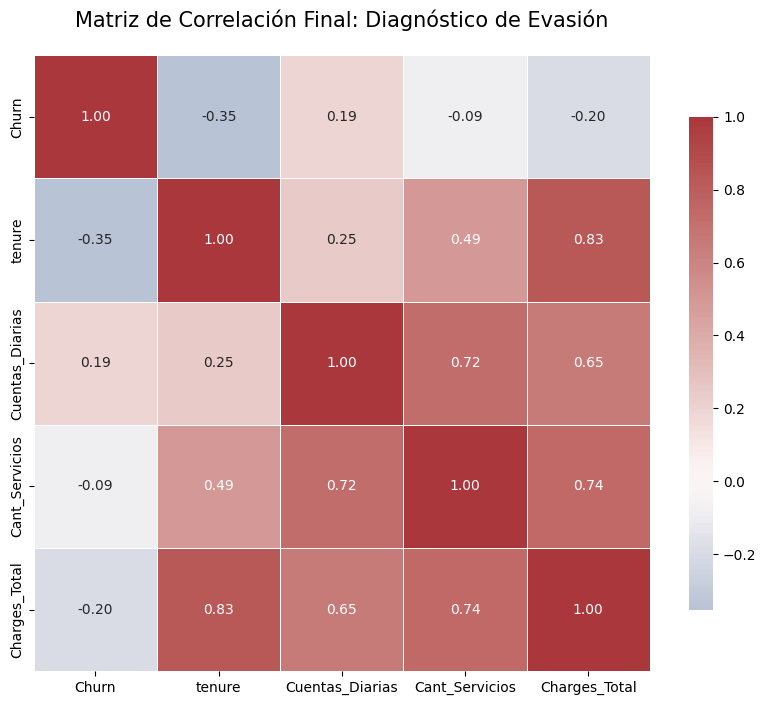

In [117]:
def graficar_correlacion():
  # Columnas de análisis
  servicios_adicionales = [
      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
      'TechSupport', 'StreamingTV', 'StreamingMovies'
  ]

  # Creando la columna Cant_Servicios
  existentes = [col for col in servicios_adicionales if col in datos.columns]
  datos['Cant_Servicios'] = datos[existentes].sum(axis=1)

  # Variables para el mapa de calor
  columnas_finales = [
      'Churn', 'tenure', 'Cuentas_Diarias',
      'Cant_Servicios', 'Charges_Total'
  ]
  matriz_final = datos[columnas_finales].corr()

  # Mostrando matriz
  plt.figure(figsize=(10, 8))

  sns.heatmap(matriz_final, annot=True, fmt=".2f", cmap='vlag', center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

  plt.title('Matriz de Correlación Final: Diagnóstico de Evasión', fontsize=15, pad=20)
  plt.show()

graficar_correlacion()

In [118]:
def mostrar_resumen_final():
  resumen_final = datos.groupby('Churn')[['tenure', 'Cuentas_Diarias', 'Cant_Servicios']].mean()
  resumen_final.index = ['Permanecieron', 'Evasión']
  print("\033[1m" + "   Perfil Comparativo: Clientes Leales vs Desertores" + "\033[0m")
  display(resumen_final.round(2))

mostrar_resumen_final()

   Perfil Comparativo: Clientes Leales vs Desertores


,tenure,Cuentas_Diarias,Cant_Servicios
Permanecieron,37.57,2.04,2.14
Evasión,17.98,2.48,1.77


# **Sección II: Informe**

---


# **Informe de Análisis de Evasión de Clientes - Telecom X**

## **I. Introducción**
La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes. Esta pérdida no solo implica la interrupción de un flujo de ingresos, sino que también conlleva un alto costo de adquisición que casi nunca se recupera si el cliente se marcha prematuramente.

## **II. Objetivo**
Este estudio tiene como objetivo realizar un diagnóstico profundo sobre el comportamiento de los clientes de Telecom X para responder las siguientes preguntas:
1.   ¿Cuál es la magnitud real del abandono?
2.   ¿Quiénes son los clientes con mayor riesgo?
3.   ¿Qué factores financieros y temporales disparan la fuga de clientes?

## **III. Limpieza y Tratamiento de Datos**
Para garantizar la integridad del análisis, los datos originales fueron sometidos a un proceso de normalización y limpieza. La fuente original es un archivo JSON con estructuras anidadas, por lo que el tratamiento técnico fue esencial para transformar la información en una tabla analítica funcional.

#### **A. Pasos del procesamiento**
<ol>
  <li><strong>Aplanamiento de Datos:</strong> Se extrajeron las dimensiones que venían anidadas en objetos (customer, phone, internet, account), consolidándolas en un DataFrame único de estructura plana.</li>
  <li><strong>Corrección de Tipos y Datos Faltantes:</strong> Se identificaron valores vacíos en la columna de Charges_Total, convirtiéndolos a formato numérico.</li>
  <li><strong>Codificación Binaria:</strong> Las variables categóricas (como Género, Tipo de Contrato, Servicio de Internet y Churn) se transformaron en indicadores numéricos mediante técnicas de codificación. Esto permitió integrar perfiles cualitativos en la Matriz de Correlación.</li>
  <li><strong>Ingeniería de Características:</strong> Se crearon dos métricas estratégicas:
  <ul>
  <li>Cuentas_Diarias: Costo diario promedio para normalizar el impacto del precio.</li>
  <li>Cant_Servicios: Variable agregada que cuantifica el nivel de adopción tecnológica.</li>
  </ul>
  <li><strong>Estandarización de Encabezados:</strong> Se realizó la limpieza y reformateo de los nombres de las columnas originales para eliminar caracteres especiales, puntos y espacios, sustituyéndolos por guiones bajos (_).</li>
  <li><strong>Validación de Calidad:</strong> Se confirmó un 0.0% de Outliers mediante el método IQR y se auditaron las varianzas mediante la Prueba de Levene.</li>
</ol>

#### **B. Verificación de la Transformación**

In [119]:
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,...,Charges_Total,InternetService_Fiber_optic,InternetService_No,Contract_One_year,Contract_Two_year,PaymentMethod_Credit_card_automatic,PaymentMethod_Electronic_check,PaymentMethod_Mailed_check,Cuentas_Diarias,Cant_Servicios
0,0002-ORFBO,0,0,0,1,1,9,1,0,0,...,593.30,0,0,1,0,0,0,1,2.186667,3
1,0003-MKNFE,0,1,0,0,0,9,1,1,0,...,542.40,0,0,0,0,0,0,1,1.996667,1
2,0004-TLHLJ,1,1,0,0,0,4,1,0,0,...,280.85,1,0,0,0,0,1,0,2.463333,1
3,0011-IGKFF,1,1,1,1,0,13,1,0,0,...,1237.85,1,0,0,0,0,1,0,3.266667,4
4,0013-EXCHZ,1,0,1,1,0,3,1,0,0,...,267.40,1,0,0,0,0,0,1,2.796667,2


#### **C. Visualización Inicial: Estado de la Evasión**

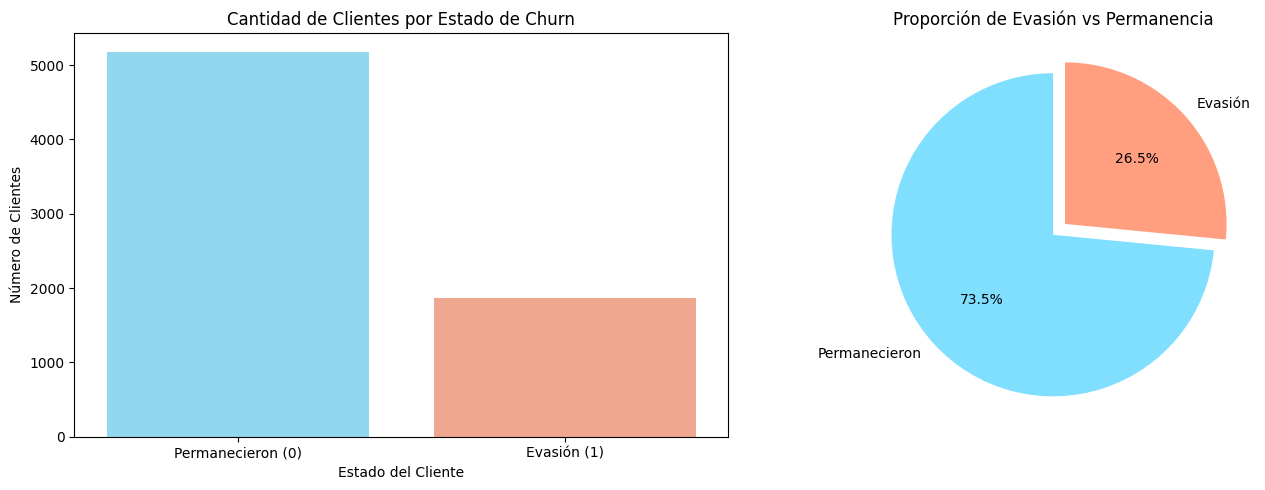

In [120]:
graficar_resumen_churn()

## **IV. Análisis Exploratorio de Datos**
Aquí vamos a identificar los patrones de comportamiento y los perfiles de riesgo.


### **A. Perfil del Cliente con Mayor Riesgo:**
Después de analizar las variables categóricas, detectamos que la evasión no es aleatoria; existen perfiles específicos donde el Churn se dispara:
<ul>
  <li><strong>Tipo de Contrato:</strong> Los clientes con contratos Mes a Mes presentan una tasa de fuga drásticamente superior a los que tienen contratos anuales.</li>
  <li><strong>Servicio de Internet:</strong> Los usuarios de Fibra Óptica, a pesar de tener una tecnología superior, muestran mayor inestabilidad.</li>
  <li><strong>Método de Pago:</strong> El uso de Cheque Electrónico está fuertemente vinculado a la evasión.</li>
</ul>

### **B. El "Umbral de Dolor" Financiero y Temporal**
Al analizar las variables numéricas, descubrimos que la decisión de irse suele ocurrir bajo condiciones específicas de tiempo y costo.
<ul>
  <li><strong>Antigüedad:</strong> Existe una "zona crítica" en los primeros 6 a 12 meses. Si un cliente supera el primer año, la probabilidad de que se quede aumenta exponencialmente.</li>
  <li><strong>Costo Diario:</strong> Nuestra variable calculada Cuentas_Diarias revela que los clientes que se van suelen tener cargos diarios más altos y volátiles que los que permanecen.</li>
</ul>

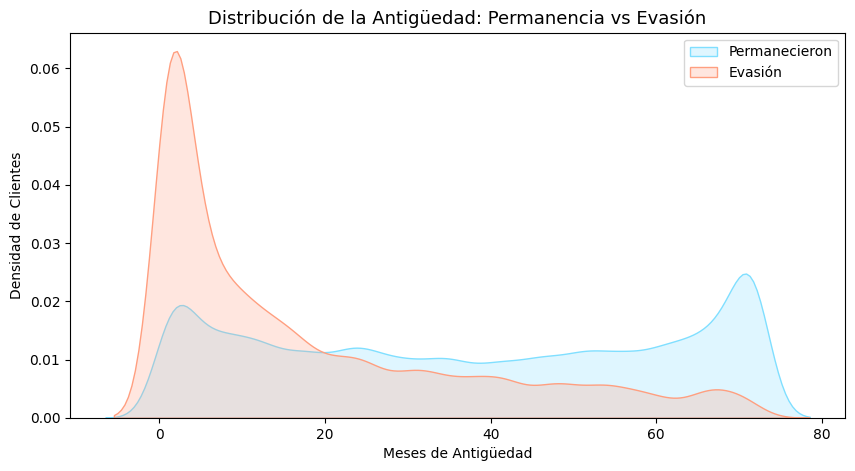

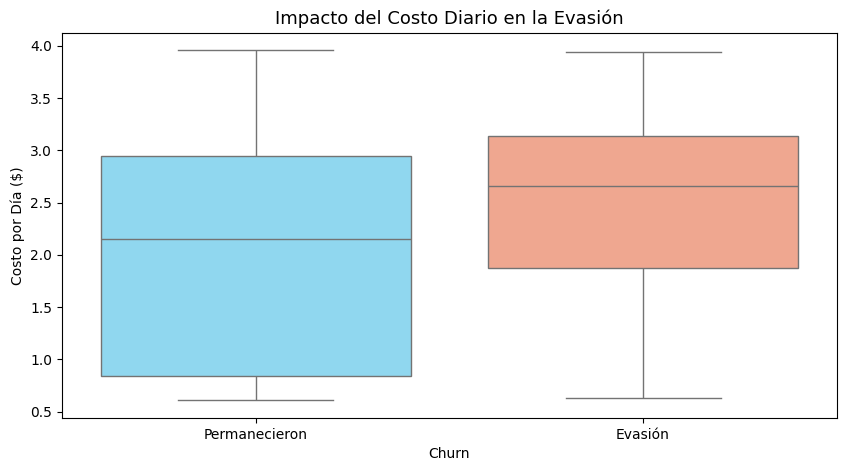

In [121]:
graficar_diagnostico()

### **C. Mapa de Relaciones (Matriz de Correlación)**
Para validar estas observaciones, utilizamos el coeficiente de correlación de Pearson.
<ul>
  <li><strong>La Variable Crítica:</strong> La antigüedad (tenure) tiene la correlación negativa más fuerte ($\rho \approx -0.35$), confirmando que el tiempo es el mejor antídoto contra el Churn.</li>
  <li><strong>El Factor Precio:</strong> El gasto diario muestra una correlación positiva, validando que el costo es un motor de expulsión.</li>
  <li><strong>Multicolinealidad:</strong> Se detectó una relación redundante entre tenure y Charges_Total ($\rho = 0.83$).</li>
</ul>

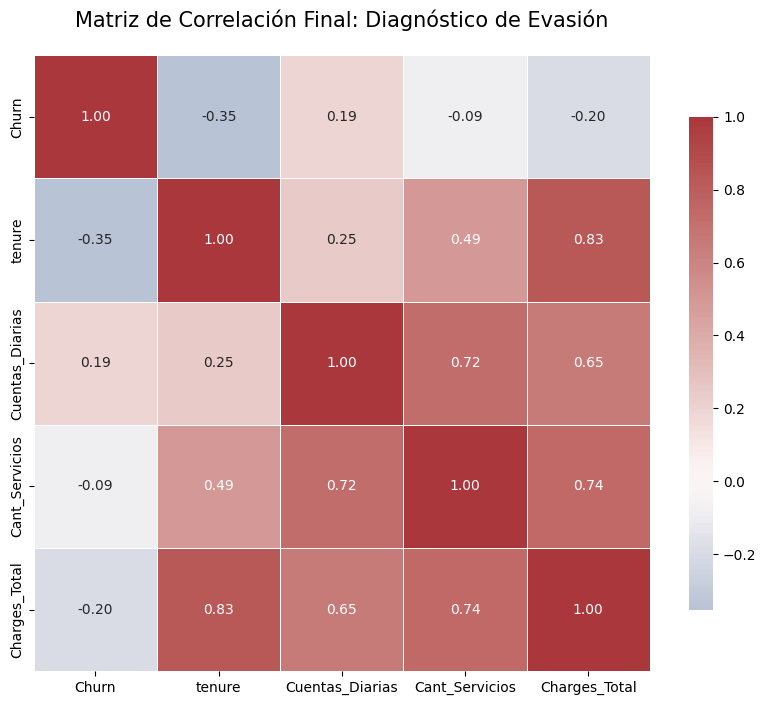

In [122]:
graficar_correlacion()

### **D. Hallazgos**
Descubrimos que Telecom X no tiene un problema de servicio general, sino un problema de retención temprana y sensibilidad al precio. El cliente no se va necesariamente porque el total sea alto, sino porque percibe que el costo diario es excesivo durante sus primeros meses de vida en la compañía.

## **V. Conclusiones e Insights**
Tras el análisis generamos cuatro conclusiones críticas que explican la evasión de clientes:

### **A. Conclusión 1:**
Los datos confirman que existe una correlación negativa moderada (-0.35) entre la antigüedad y el Churn. Los clientes no se van por un desgaste a largo plazo, sino por una falta de consolidación en el corto plazo.
<ul>
  <li><strong>Insight:</strong> El riesgo de fuga es máximo durante los primeros 12 meses. Una vez superada esta barrera, el cliente entra en una zona de lealtad donde el "costo de salida" se vuelve un aliado de la empresa.</li>
</ul>


### **B. Conclusión 2:**
Descubrimos que Cuentas_Diarias es un predictor más honesto que el gasto total.
<ul>
  <li><strong>Insight:</strong> La evasión está impulsada por la percepción del valor diario. Los clientes que se van pagan, en promedio, un costo por día más alto. No es la factura mensual lo que asusta al cliente, sino sentir que el servicio es "caro" en el día a día, especialmente si no perciben un beneficio diferencial.</li>
</ul>


### **C. Conclusión 3:**
Contrario a la creencia popular de que "a más servicios contratados, más difícil es que el cliente se vaya", nuestra variable Cant_Servicios mostró una correlación casi nula (-0.09).
<ul>
  <li><strong>Insight:</strong> La cantidad de servicios adicionales (Streaming, soporte técnico, etc.) no es un seguro contra el Churn. Un cliente con *varios* productos se irá igual si siente que el costo diario es excesivo o si tiene un contrato de corto plazo.</li>
</ul>

### **D. Conclusión 4:**
Al cruzar los datos, hemos identificado el perfil de cliente con riesgo inminente de fuga:
<ul>
  <li>Contrato Mes a Mes (Baja barrera de salida).</li>
  <li>Uso de Fibra Óptica (Alta volatilidad de mercado).</li>
  <li>Método de pago por Cheque Electrónico (Falta de automatización y fidelidad bancaria).</li>
  <li>Antigüedad menor a 6 meses.</li>
</ul>

### **E. Conclusión 5:**
La evasión de clientes en Telecom X es un problema de fidelización temprana y optimización tarifaria.

### **F. Conclusión 6:**

In [123]:
mostrar_resumen_final()

   Perfil Comparativo: Clientes Leales vs Desertores


,tenure,Cuentas_Diarias,Cant_Servicios
Permanecieron,37.57,2.04,2.14
Evasión,17.98,2.48,1.77


De la tabla **Perfil Comparativo: Clientes Leales vs Desertores** concluimos que el cliente que logramos retener promedia 37 meses de vida, mientras que el que deserta promedia apenas 18 meses.

## **VI. Recomendaciones**
<ol>
<li>Dado que el pico de fuga ocurre antes del mes 12, la empresa debe implementar un plan de acompañamiento. Se recomienda crear en el mes 9 un hito de fidelización, ofrecer una mejora de plan o un beneficio exclusivo, con la finalidad de empujar al cliente desde el mes 17 hacia la zona segura" de los 37 meses.</li>
<li>Como el análisis demostró que el precio por día es el principal expulsor, se debe migrar a los clientes de alto costo diario hacia contratos de largo plazo con una tarifa diaria reducida.</li>
<li>Se ha comprobado que añadir servicios adicionales por sí solo no retiene al cliente; por ello, se debe dejar de usar los servicios adicionales como simples regalos y empezar a usarlos como herramientas de anclaje. Una posible estrategia podria ser vincular los servicios premium a contratos anuales</li>
<li>En el perfil de riesgo estan usuarios de Fibra Óptica y pago por Cheque Electrónico; por lo que, se debe incentivar la migración de Cheque Electrónico a Cargo Automático mediante un pequeño bono de retención</li>
</ul>